In [1]:
import numpy as np
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from model import GalerkinSARIMA
import time
import warnings


In [2]:
warnings.filterwarnings("ignore")
np.random.seed(123)

txt_path = "HadCRUT5.1.txt"
m_seasonal = 12  # Monthly data

def _to_stationary(x: pd.Series) -> pd.Series:
    """Convert to stationary series using differencing."""
    x = x.astype(float)
    return x.diff().dropna()

def _treat_outliers(x: pd.Series, method='winsorize', lower=0.01, upper=0.99):
    """
    Treat outliers in the time series.
    
    Parameters:
    - method: 'winsorize' (clip extreme values) or 'remove' (remove outliers)
    - lower: Lower percentile for winsorization (default 0.01 = 1st percentile)
    - upper: Upper percentile for winsorization (default 0.99 = 99th percentile)
    """
    if method == 'winsorize':
        lower_bound = x.quantile(lower)
        upper_bound = x.quantile(upper)
        return x.clip(lower=lower_bound, upper=upper_bound)
    elif method == 'remove':
        # Remove values beyond 3 standard deviations
        mean = x.mean()
        std = x.std()
        return x[(x >= mean - 3*std) & (x <= mean + 3*std)]
    else:
        return x


In [3]:
# Parse HadCRUT5.1.txt file
# Format: Year, Jan, Feb, ..., Dec, Annual, then coverage row
def parse_hadcrut5_file(filepath):
    """Parse HadCRUT5.1.txt file and return monthly time series."""
    data = []
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line or line.startswith('#'):
            i += 1
            continue
        
        parts = line.split()
        if len(parts) < 13:  # Need at least year + 12 months
            i += 1
            continue
        
        try:
            year = int(parts[0])
            # Extract 12 monthly values (columns 1-12)
            monthly_values = []
            for j in range(1, 13):
                val = float(parts[j])
                # -9.999 indicates missing data
                if val < -9.0:  # Missing value code
                    monthly_values.append(np.nan)
                else:
                    monthly_values.append(val)
            
            # Create dates for each month of this year
            for month_idx, temp_val in enumerate(monthly_values, 1):
                date = pd.Timestamp(year, month_idx, 1)
                data.append({'date': date, 'temperature': temp_val})
            
            # Skip the next line (coverage data)
            i += 2
        except (ValueError, IndexError):
            i += 1
    
    df = pd.DataFrame(data)
    df = df.set_index('date').sort_index()
    return df['temperature']

# Load and process HadCRUT5 data
y_level = parse_hadcrut5_file(txt_path)
print(f"Loaded {len(y_level)} monthly observations")
print(f"Date range: {y_level.index.min()} to {y_level.index.max()}")
print(f"Missing values: {y_level.isna().sum()}")

# Handle missing values (forward fill, then backward fill if needed)
y_level = y_level.ffill().bfill()

# Option to exclude recent period if needed
exclude_recent = False  # Set to True to exclude recent years
if exclude_recent:
    cutoff_date = pd.Timestamp('2020-01-01')
    print(f"Excluding data after {cutoff_date.date()}")
    y_level = y_level[y_level.index < cutoff_date]

# Convert to stationary series
y = _to_stationary(y_level).replace([np.inf, -np.inf], np.nan).dropna()

# Normalize the stationary series (z-score normalization)
series_mean = y.mean()
series_std = y.std()
y_normalized = (y - series_mean) / series_std

series_hadcrut = y_normalized.values

# Store the date index corresponding to the series (after differencing/transformation)
# This will be used for plotting with dates on x-axis
date_index_hadcrut = y.index

# Store normalization parameters for potential denormalization later
normalization_params = {
    'mean': series_mean,
    'std': series_std
}

datasets = {'HadCRUT5_Temperature': series_hadcrut}
date_indices = {'HadCRUT5_Temperature': date_index_hadcrut}

print(f"\nFinal series length: {len(series_hadcrut)} months")
print(f"Date range: {date_index_hadcrut.min()} to {date_index_hadcrut.max()}")


Loaded 2112 monthly observations
Date range: 1850-01-01 00:00:00 to 2025-12-01 00:00:00
Missing values: 3

Final series length: 2111 months
Date range: 1850-02-01 00:00:00 to 2025-12-01 00:00:00


In [ ]:
window = 120  # Training window size (120 months = 10 years before testing period)
horizon = 120  # Testing window size (last 120 months = 10 years)
num_runs = 5

p_values = [0,1,5]
q_values = [0,1,5]
P_values = [0,1,5]
Q_values = [0,1,5]

orders = [(p, q, P, Q) for p in p_values for q in q_values for P in P_values for Q in Q_values]
forecast_steps = 1

# Rolling window setup: test on last horizon points, train on window points before that
# Test period: indices [len(series) - horizon : len(series)]
# Training period: indices [len(series) - horizon - window : len(series) - horizon]
for name, series in datasets.items():
    if len(series) < window + horizon:
        adjusted_horizon = max(24, len(series) - window)
        print(f"Warning: Adjusted horizon for {name} to {adjusted_horizon} due to insufficient data (have {len(series)} points, need {window + horizon})")
        horizon = adjusted_horizon


In [5]:
all_results = []
first_run_preds = {}  # Store predictions from first run for plotting

# Define algorithms to run
algorithms = [
    {'name': 'GARIMA-OLS', 'use_ridge': False},
    {'name': 'GARIMA-Ridge', 'use_ridge': True, 'ridge_lambda_ar': 1.5, 'ridge_lambda_ma': 1.0, 
     'ridge_weight_scheme': 'poly', 'ridge_eta': 1.5},
    {'name': 'ARIMA', 'is_statsmodels': True},
]

for run in range(1, num_runs + 1):
    runs_left = num_runs - run
    print(f"\n=== Run {run}/{num_runs}  (runs left after this: {runs_left}) ===")
    
    for name, series in datasets.items():
        m = m_seasonal
        n = len(series)
        
        # Rolling window: test on last horizon points
        test_start_idx = n - horizon
        test_end_idx = n
        y_true = series[test_start_idx:test_end_idx]
        
        for p, q, P, Q in tqdm(orders, desc=f"Param combos for {name}", total=len(orders), leave=False):
            # Run each algorithm
            for alg_config in algorithms:
                alg_name = alg_config['name']
                preds = []
                iter_times = []
                
                combo_start = time.perf_counter()
                
                # Rolling window: for each test point, train on window points before it
                for test_idx in range(test_start_idx, test_end_idx):
                    t0 = time.perf_counter()
                    # Train on window points before this test point
                    train_start_idx = max(0, test_idx - window)
                    train = series[train_start_idx:test_idx]
                    
                    try:
                        if alg_config.get('is_statsmodels', False):
                            # ARIMA from statsmodels
                            model = ARIMA(train, order=(p, 0, q), seasonal_order=(P, 0, Q, m))
                            model_fit = model.fit(method_kwargs={"warn_convergence": False})
                            pred_vec = model_fit.forecast(steps=forecast_steps)
                            pred = float(pred_vec[-1])
                        else:
                            # GalerkinSARIMA (OLS or Ridge)
                            model = GalerkinSARIMA(
                                train,
                                order=(p, 0, q),
                                seasonal_order=(P, 0, Q, m),
                                basis_functions=["linear", "quadratic"],
                                forecast_method="direct",
                                use_ridge=alg_config['use_ridge'],
                                ridge_lambda_ar=alg_config.get('ridge_lambda_ar', 1.0),
                                ridge_lambda_ma=alg_config.get('ridge_lambda_ma', 1.0),
                                ridge_weight_scheme=alg_config.get('ridge_weight_scheme', 'none'),
                                ridge_eta=alg_config.get('ridge_eta', 1.0),
                                standardize=True
                            )
                            model.fit(train)
                            pred_vec = model.forecast(steps=forecast_steps)
                            pred = pred_vec[-1] if np.ndim(pred_vec) > 0 else float(pred_vec)
                        
                        preds.append(float(pred))
                    except Exception as e:
                        # If fitting fails, use last value
                        preds.append(float(train[-1]))
                    
                    iter_times.append(time.perf_counter() - t0)
                
                combo_sec = time.perf_counter() - combo_start
                
                preds = np.asarray(preds, dtype=float)
                
                # Store predictions from first run for plotting
                if run == 1:
                    first_run_preds[(name, p, q, P, Q, alg_name)] = preds
                
                # Calculate metrics
                mask = np.isfinite(y_true) & np.isfinite(preds)
                mae = mean_absolute_error(y_true[mask], preds[mask]) if mask.any() else np.nan
                rmse = np.sqrt(mean_squared_error(y_true[mask], preds[mask])) if mask.any() else np.nan
                
                # Timing stats
                mean_iter_ms = float(np.mean(iter_times)) * 1000 if len(iter_times) else np.nan
                median_iter_ms = float(np.median(iter_times)) * 1000 if len(iter_times) else np.nan
                max_iter_ms = float(np.max(iter_times)) * 1000 if len(iter_times) else np.nan
                throughput = (len(iter_times) / combo_sec) if combo_sec > 0 else np.nan
                
                all_results.append([
                    name, p, q, P, Q, run, alg_name,
                    mae, rmse,
                    mean_iter_ms, median_iter_ms, max_iter_ms,
                    combo_sec, len(iter_times), throughput
                ])

df = pd.DataFrame(
    all_results,
    columns=[
        'Dataset', 'p', 'q', 'P', 'Q', 'Run', 'Alg',
        'MAE', 'RMSE',
        'mean_iter_ms', 'median_iter_ms', 'max_iter_ms',
        'combo_sec', 'num_iters', 'throughput_iters_per_sec'
    ]
)
agg = df.groupby(['Dataset', 'p', 'q', 'P', 'Q', 'Alg'], as_index=False).mean(numeric_only=True)
print("\nAveraged over {} runs (including timing):\n".format(num_runs))
try:
    print(agg.to_markdown(index=False, floatfmt=".4f"))
except Exception:
    print(agg)
results = agg



=== Run 1/1  (runs left after this: 0) ===



Averaged over 1 runs (including timing):

| Dataset              |   p |   q |   P |   Q | Alg          |    Run |    MAE |   RMSE |   mean_iter_ms |   median_iter_ms |   max_iter_ms |   combo_sec |   num_iters |   throughput_iters_per_sec |
|:---------------------|----:|----:|----:|----:|:-------------|-------:|-------:|-------:|---------------:|-----------------:|--------------:|------------:|------------:|---------------------------:|
| HadCRUT5_Temperature |   0 |   0 |   0 |   0 | ARIMA        | 1.0000 | 0.5651 | 0.7173 |         9.2067 |           8.0639 |       80.0446 |      1.1049 |    120.0000 |                   108.6078 |
| HadCRUT5_Temperature |   0 |   0 |   0 |   0 | GARIMA-OLS   | 1.0000 | 0.5651 | 0.7173 |         0.2933 |           0.2683 |        0.9608 |      0.0352 |    120.0000 |                  3405.9261 |
| HadCRUT5_Temperature |   0 |   0 |   0 |   0 | GARIMA-Ridge | 1.0000 | 0.5651 | 0.7173 |         0.5544 |           0.3419 |        3.9474 |      0.0666 | 

In [6]:
best_results = pd.concat([
    agg.groupby(['Dataset', 'Alg']).apply(lambda x: x.loc[x['MAE'].idxmin()]).assign(Metric='Best MAE'),
    agg.groupby(['Dataset', 'Alg']).apply(lambda x: x.loc[x['RMSE'].idxmin()]).assign(Metric='Best RMSE')
])

best_results


Dataset  p  q  P  Q  \
Dataset              Alg                                              
HadCRUT5_Temperature ARIMA         HadCRUT5_Temperature  1  0  1  1   
                     GARIMA-OLS    HadCRUT5_Temperature  1  0  0  1   
                     GARIMA-Ridge  HadCRUT5_Temperature  1  0  0  1   
                     ARIMA         HadCRUT5_Temperature  1  0  1  1   
                     GARIMA-OLS    HadCRUT5_Temperature  0  1  0  0   
                     GARIMA-Ridge  HadCRUT5_Temperature  0  1  0  0   

                                            Alg  Run       MAE      RMSE  \
Dataset              Alg                                                   
HadCRUT5_Temperature ARIMA                ARIMA  1.0  0.527499  0.688357   
                     GARIMA-OLS      GARIMA-OLS  1.0  0.551496  0.707369   
                     GARIMA-Ridge  GARIMA-Ridge  1.0  0.549704  0.707404   
                     ARIMA                ARIMA  1.0  0.527499  0.688357   
                     GARIMA-OLS      GARIMA-OLS  1.0  0.552922  0.705245   
                     GARIMA-Ridge  GARIMA-Ridge  1.0  0.550233  0.703434   

                                   mean_iter_ms  median_iter_ms  max_iter_ms  \
Dataset              Alg                                                       
HadCRUT5_Temperature ARIMA            81.202104       58.064271   250.424292   
                     GARIMA-OLS        0.776561        0.748146     1.108958   
                     GARIMA-Ridge      0.872861        0.856396     1.171792   
                     ARIMA            81.202104       58.064271   250.424292   
                     GARIMA-OLS        0.735940        0.701771     1.127250   
                     GARIMA-Ridge      0.828381        0.805438     1.042834   

                                   combo_sec  num_iters  \
Dataset              Alg                                  
HadCRUT5_Temperature ARIMA          9.744334      120.0   
                     GARIMA-OLS     0.093214      120.0   
                     GARIMA-Ridge   0.104769      120.0   
                     ARIMA          9.744334      120.0   
                     GARIMA-OLS     0.088341      120.0   
                     GARIMA-Ridge   0.099430      120.0   

                                   throughput_iters_per_sec     Metric  
Dataset              Alg                                                
HadCRUT5_Temperature ARIMA                        12.314849   Best MAE  
                     GARIMA-OLS                 1287.364286   Best MAE  
                     GARIMA-Ridge               1145.375604   Best MAE  
                     ARIMA                        12.314849  Best RMSE  
                     GARIMA-OLS                 1358.375225  Best RMSE  
                     GARIMA-Ridge               1206.882242  Best RMSE

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p0_q0_P0_Q0_m12.png


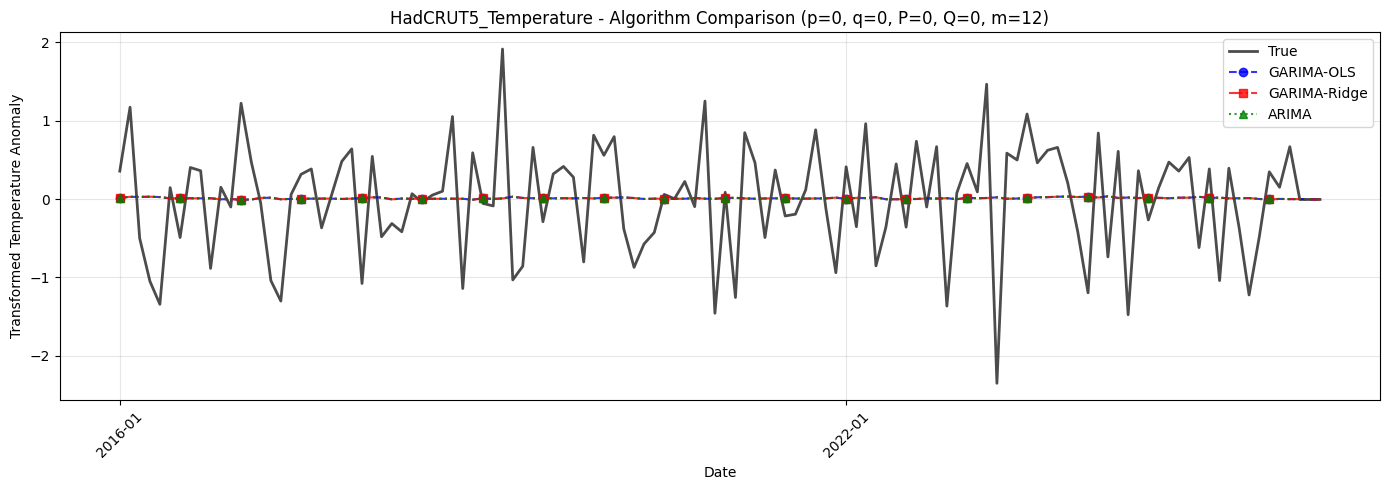


HadCRUT5_Temperature (p=0, q=0, P=0, Q=0):
  ARIMA           - MAE: 0.5651, RMSE: 0.7173, Time: 1.10s
  GARIMA-OLS      - MAE: 0.5651, RMSE: 0.7173, Time: 0.04s
  GARIMA-Ridge    - MAE: 0.5651, RMSE: 0.7173, Time: 0.07s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p0_q0_P0_Q1_m12.png


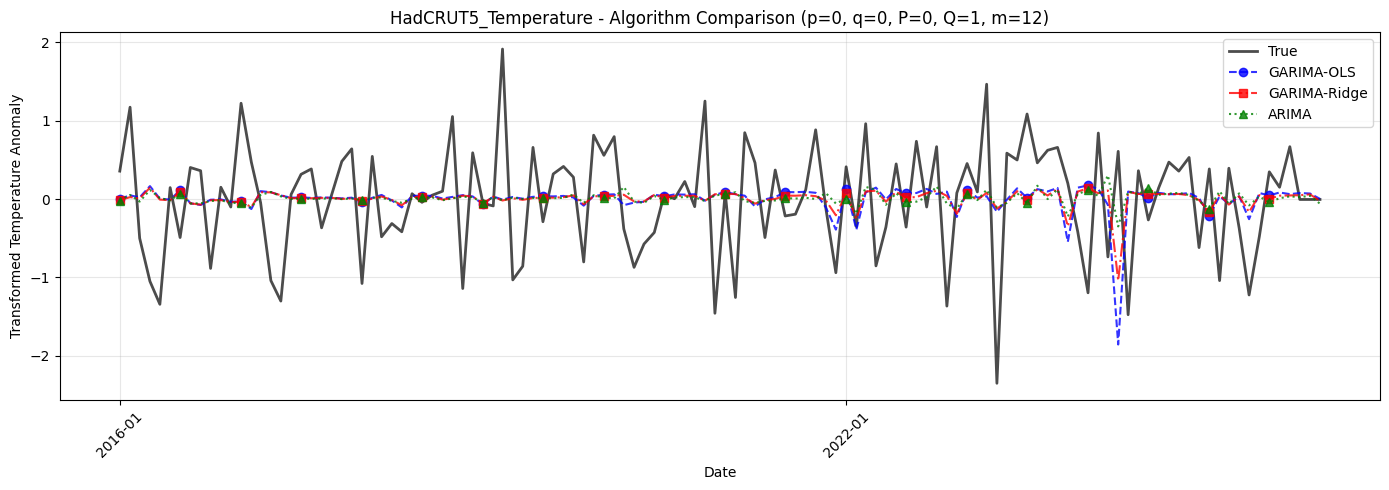


HadCRUT5_Temperature (p=0, q=0, P=0, Q=1):
  ARIMA           - MAE: 0.5720, RMSE: 0.7230, Time: 2.33s
  GARIMA-OLS      - MAE: 0.5740, RMSE: 0.7442, Time: 0.07s
  GARIMA-Ridge    - MAE: 0.5738, RMSE: 0.7293, Time: 0.08s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p0_q0_P1_Q0_m12.png


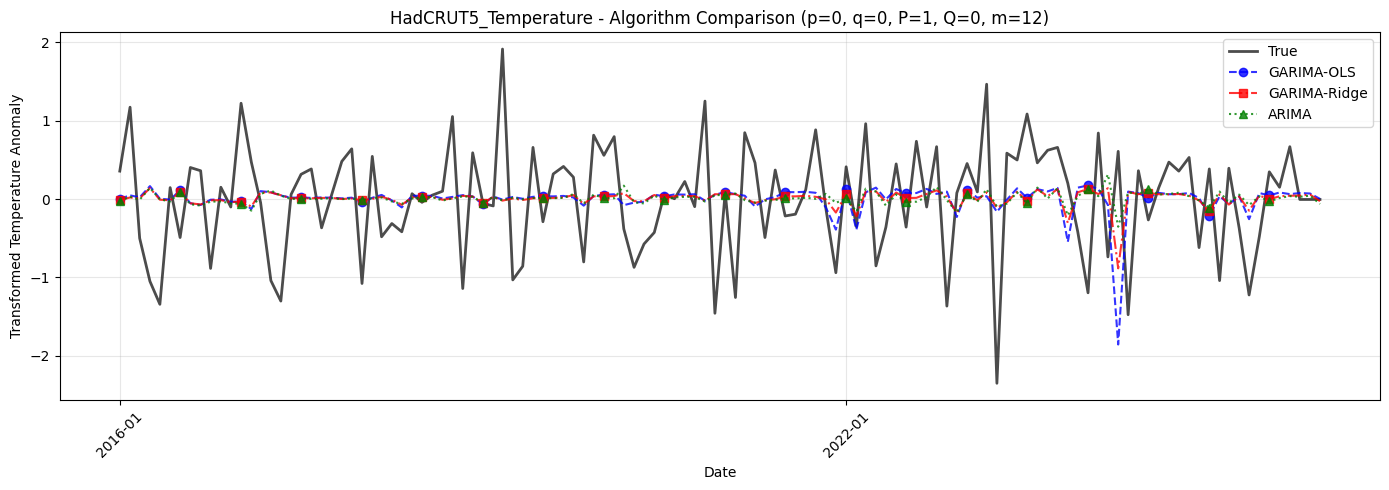


HadCRUT5_Temperature (p=0, q=0, P=1, Q=0):
  ARIMA           - MAE: 0.5742, RMSE: 0.7251, Time: 2.21s
  GARIMA-OLS      - MAE: 0.5740, RMSE: 0.7442, Time: 0.04s
  GARIMA-Ridge    - MAE: 0.5738, RMSE: 0.7274, Time: 0.05s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p0_q0_P1_Q1_m12.png


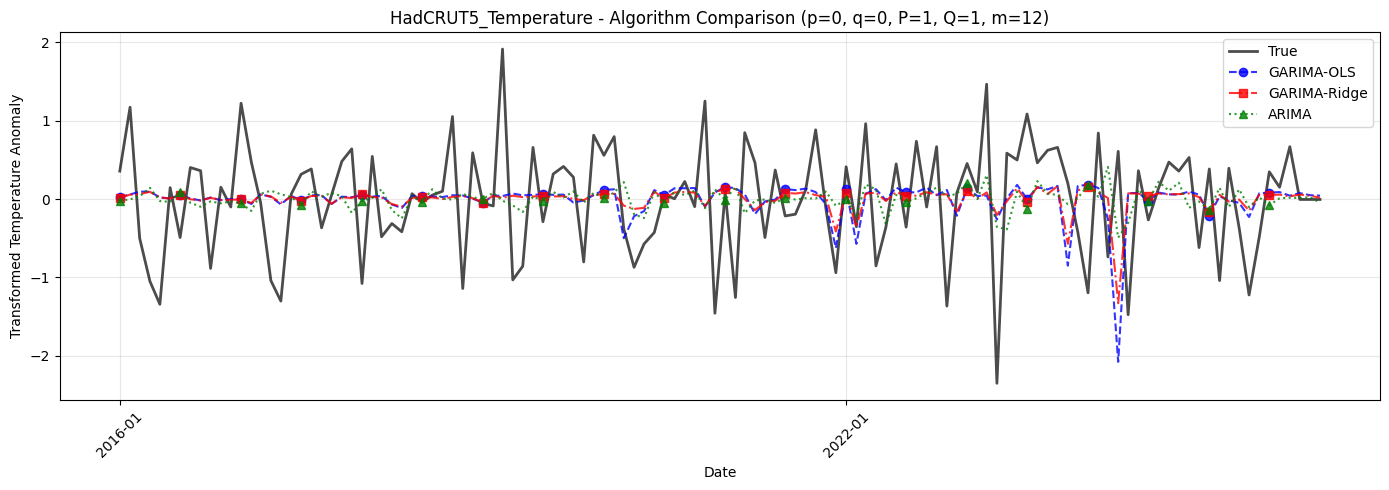


HadCRUT5_Temperature (p=0, q=0, P=1, Q=1):
  ARIMA           - MAE: 0.5655, RMSE: 0.7197, Time: 9.03s
  GARIMA-OLS      - MAE: 0.5704, RMSE: 0.7457, Time: 0.08s
  GARIMA-Ridge    - MAE: 0.5706, RMSE: 0.7303, Time: 0.09s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p0_q1_P0_Q0_m12.png


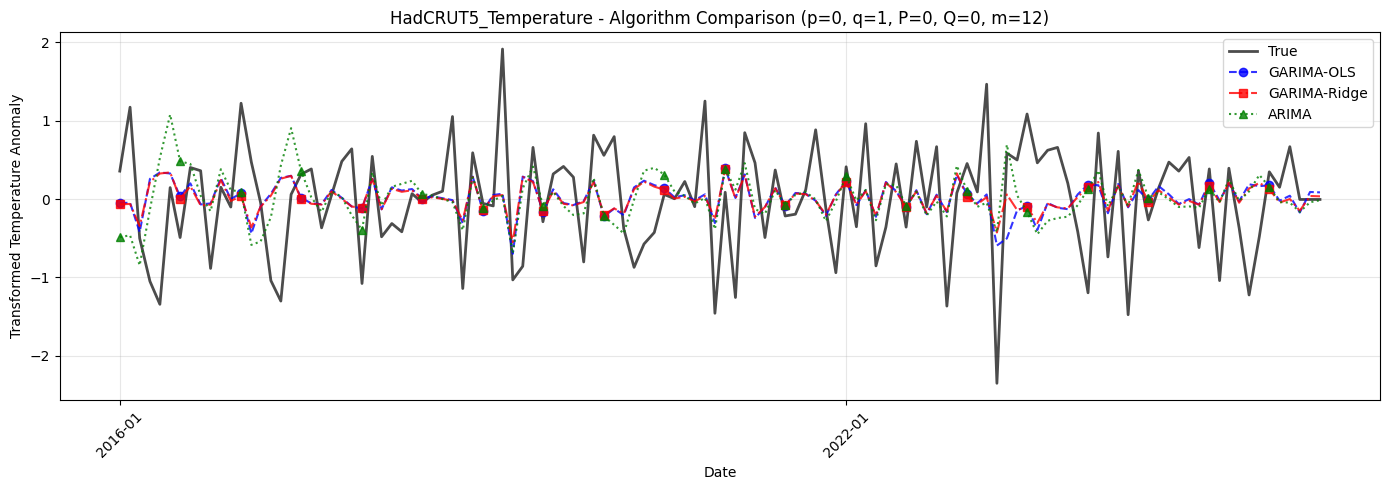


HadCRUT5_Temperature (p=0, q=1, P=0, Q=0):
  ARIMA           - MAE: 0.5687, RMSE: 0.7275, Time: 1.09s
  GARIMA-OLS      - MAE: 0.5529, RMSE: 0.7052, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.5502, RMSE: 0.7034, Time: 0.10s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p0_q1_P0_Q1_m12.png


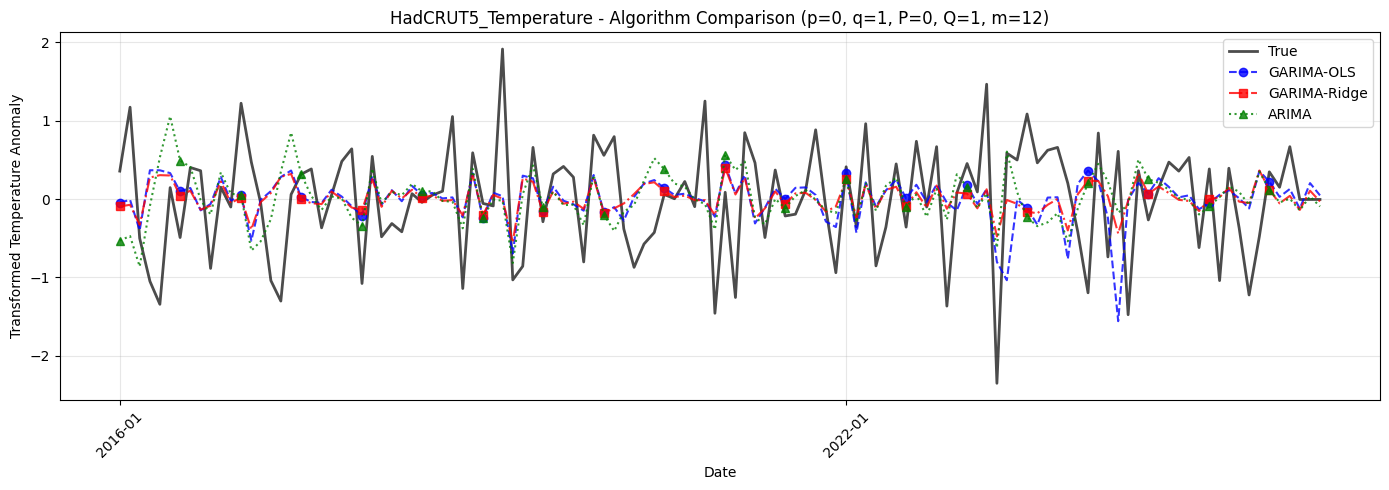


HadCRUT5_Temperature (p=0, q=1, P=0, Q=1):
  ARIMA           - MAE: 0.5687, RMSE: 0.7293, Time: 3.72s
  GARIMA-OLS      - MAE: 0.5696, RMSE: 0.7379, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.5546, RMSE: 0.7106, Time: 0.10s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p0_q1_P1_Q0_m12.png


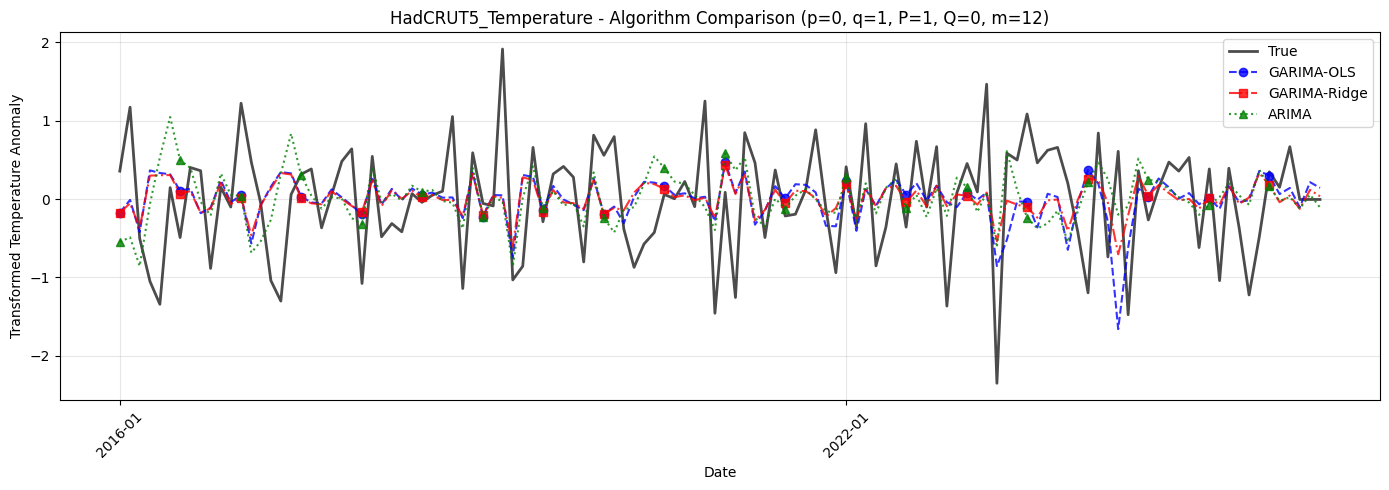


HadCRUT5_Temperature (p=0, q=1, P=1, Q=0):
  ARIMA           - MAE: 0.5667, RMSE: 0.7298, Time: 3.37s
  GARIMA-OLS      - MAE: 0.5579, RMSE: 0.7217, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.5540, RMSE: 0.7107, Time: 0.10s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p0_q1_P1_Q1_m12.png


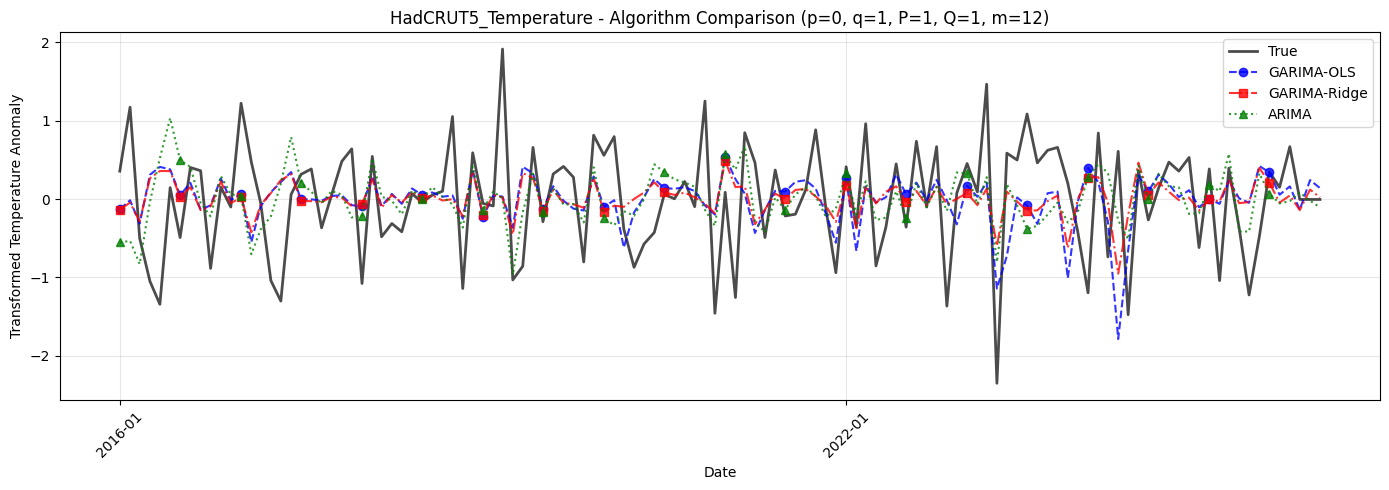


HadCRUT5_Temperature (p=0, q=1, P=1, Q=1):
  ARIMA           - MAE: 0.5368, RMSE: 0.7050, Time: 10.80s
  GARIMA-OLS      - MAE: 0.5636, RMSE: 0.7299, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.5555, RMSE: 0.7142, Time: 0.10s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p1_q0_P0_Q0_m12.png


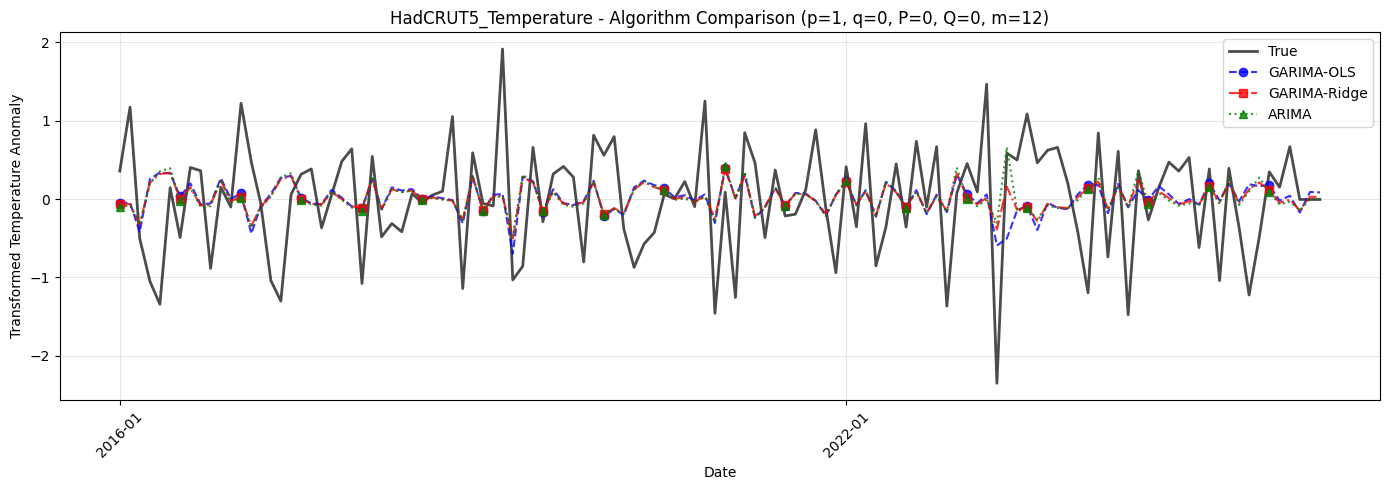


HadCRUT5_Temperature (p=1, q=0, P=0, Q=0):
  ARIMA           - MAE: 0.5485, RMSE: 0.7064, Time: 0.96s
  GARIMA-OLS      - MAE: 0.5529, RMSE: 0.7052, Time: 0.06s
  GARIMA-Ridge    - MAE: 0.5498, RMSE: 0.7036, Time: 0.06s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p1_q0_P0_Q1_m12.png


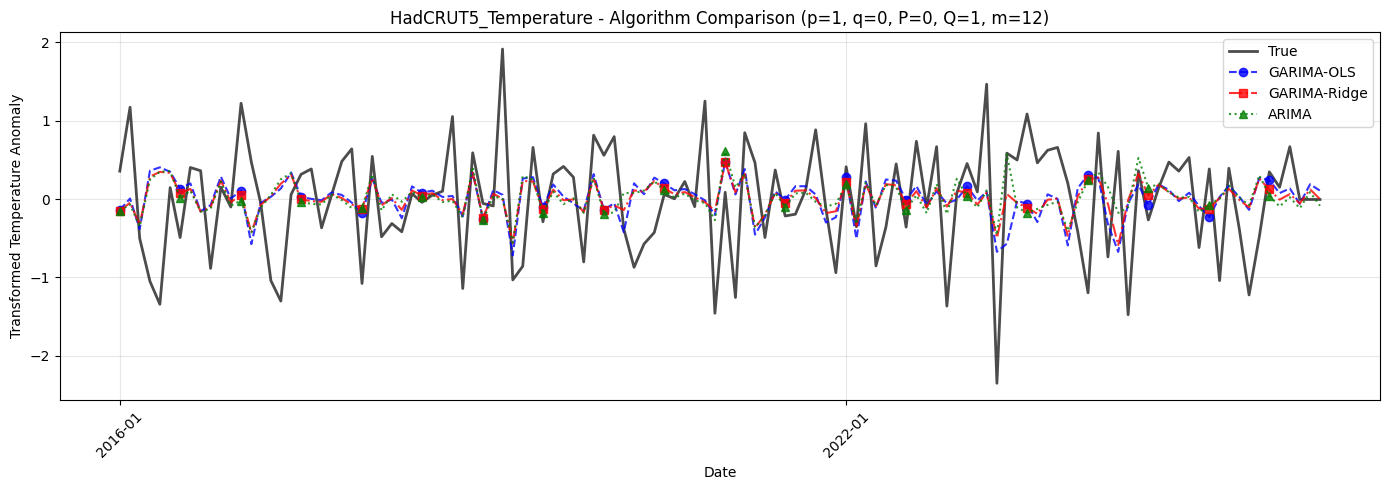


HadCRUT5_Temperature (p=1, q=0, P=0, Q=1):
  ARIMA           - MAE: 0.5524, RMSE: 0.7087, Time: 3.06s
  GARIMA-OLS      - MAE: 0.5515, RMSE: 0.7074, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.5497, RMSE: 0.7074, Time: 0.10s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p1_q0_P1_Q0_m12.png


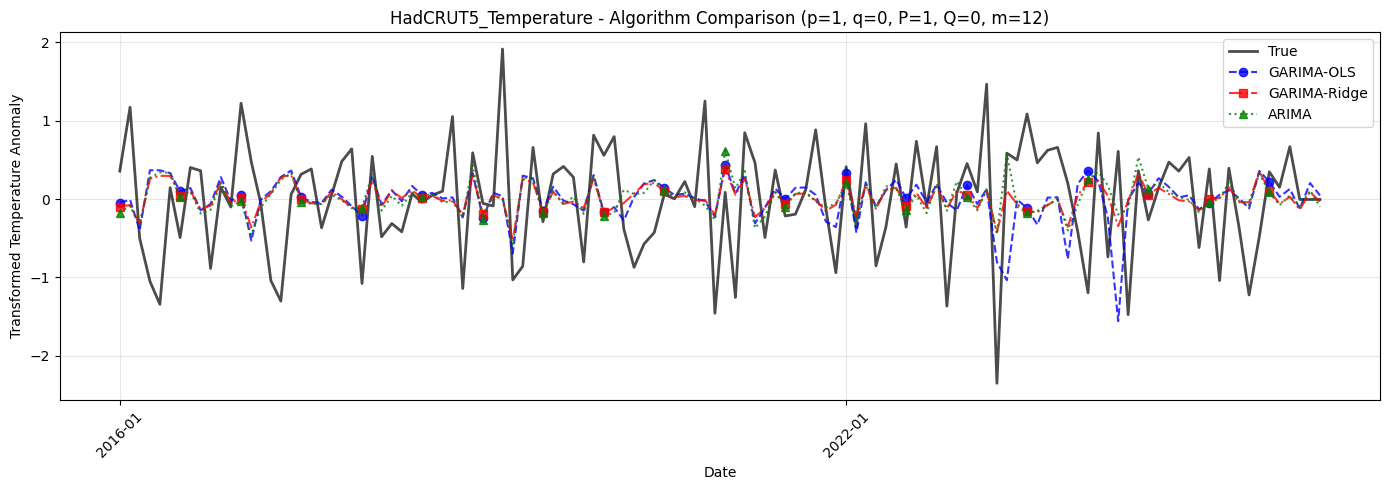


HadCRUT5_Temperature (p=1, q=0, P=1, Q=0):
  ARIMA           - MAE: 0.5511, RMSE: 0.7096, Time: 3.36s
  GARIMA-OLS      - MAE: 0.5696, RMSE: 0.7379, Time: 0.06s
  GARIMA-Ridge    - MAE: 0.5537, RMSE: 0.7096, Time: 0.06s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p1_q0_P1_Q1_m12.png


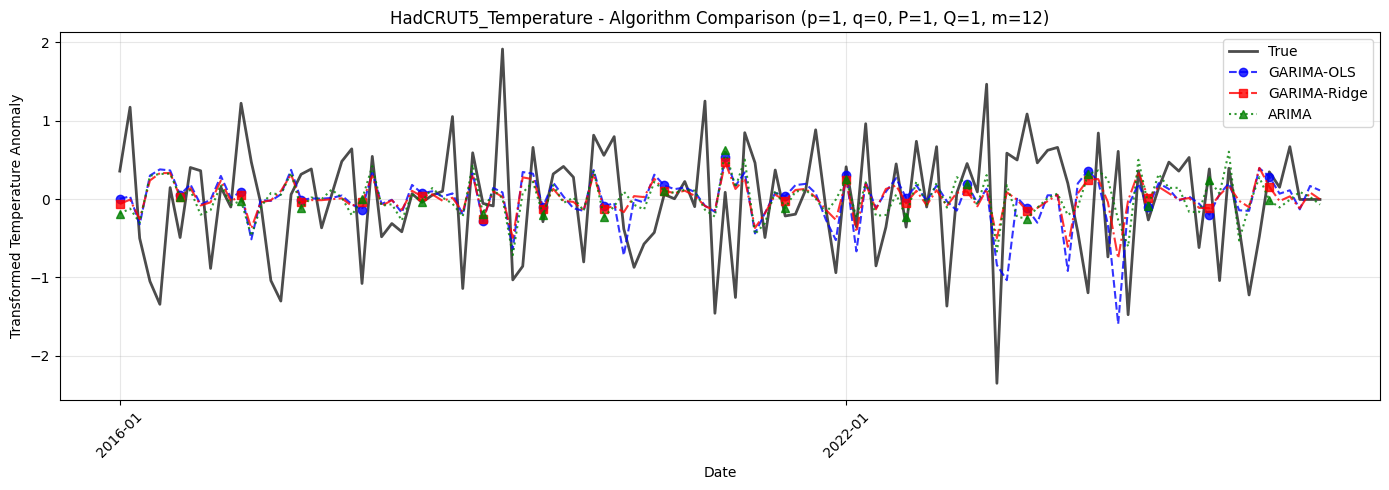


HadCRUT5_Temperature (p=1, q=0, P=1, Q=1):
  ARIMA           - MAE: 0.5275, RMSE: 0.6884, Time: 9.74s
  GARIMA-OLS      - MAE: 0.5654, RMSE: 0.7313, Time: 0.09s
  GARIMA-Ridge    - MAE: 0.5500, RMSE: 0.7081, Time: 0.10s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p1_q1_P0_Q0_m12.png


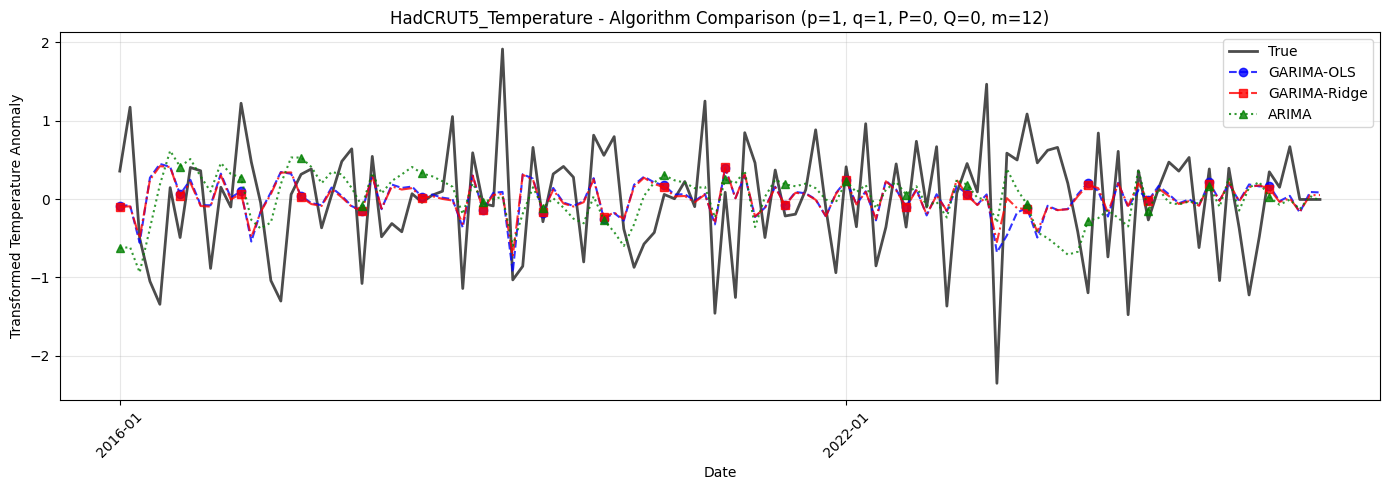


HadCRUT5_Temperature (p=1, q=1, P=0, Q=0):
  ARIMA           - MAE: 0.5744, RMSE: 0.7201, Time: 2.50s
  GARIMA-OLS      - MAE: 0.5554, RMSE: 0.7108, Time: 0.11s
  GARIMA-Ridge    - MAE: 0.5526, RMSE: 0.7079, Time: 0.12s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p1_q1_P0_Q1_m12.png


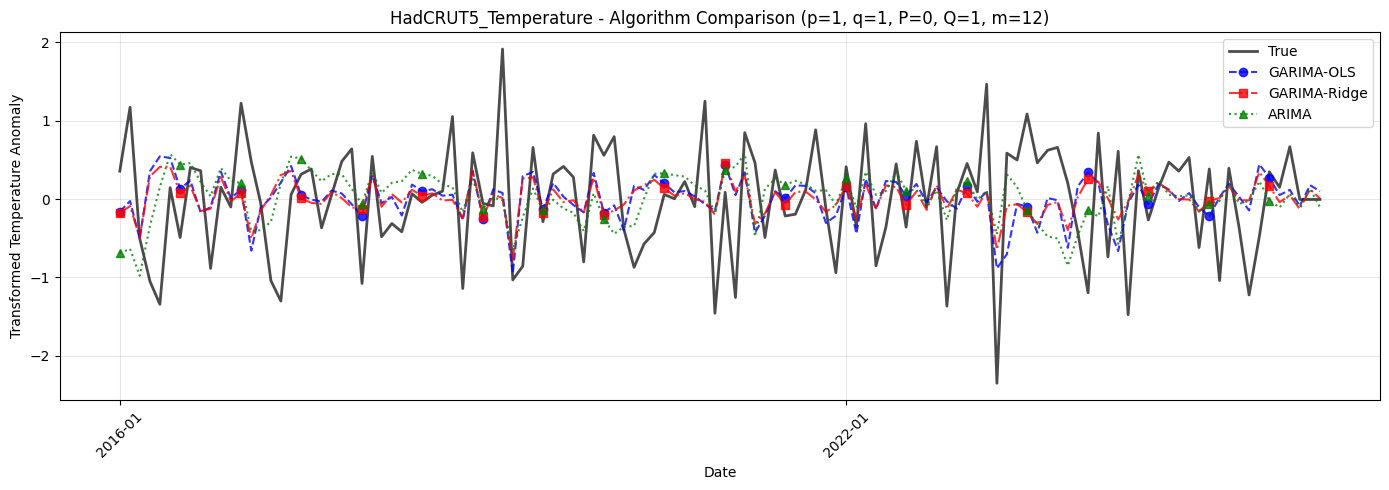


HadCRUT5_Temperature (p=1, q=1, P=0, Q=1):
  ARIMA           - MAE: 0.5828, RMSE: 0.7321, Time: 8.49s
  GARIMA-OLS      - MAE: 0.5598, RMSE: 0.7170, Time: 0.11s
  GARIMA-Ridge    - MAE: 0.5554, RMSE: 0.7109, Time: 0.19s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p1_q1_P1_Q0_m12.png


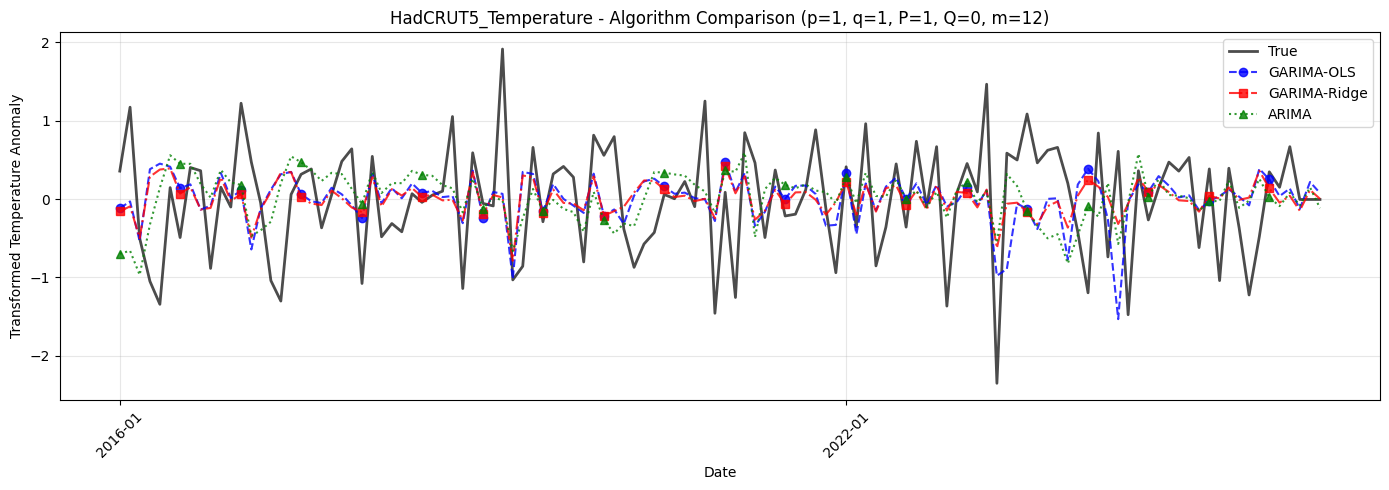


HadCRUT5_Temperature (p=1, q=1, P=1, Q=0):
  ARIMA           - MAE: 0.5802, RMSE: 0.7299, Time: 8.83s
  GARIMA-OLS      - MAE: 0.5669, RMSE: 0.7351, Time: 0.11s
  GARIMA-Ridge    - MAE: 0.5555, RMSE: 0.7104, Time: 0.12s

Saved: HadCRUT5_comparison_plots/HadCRUT5_Temperature_p1_q1_P1_Q1_m12.png


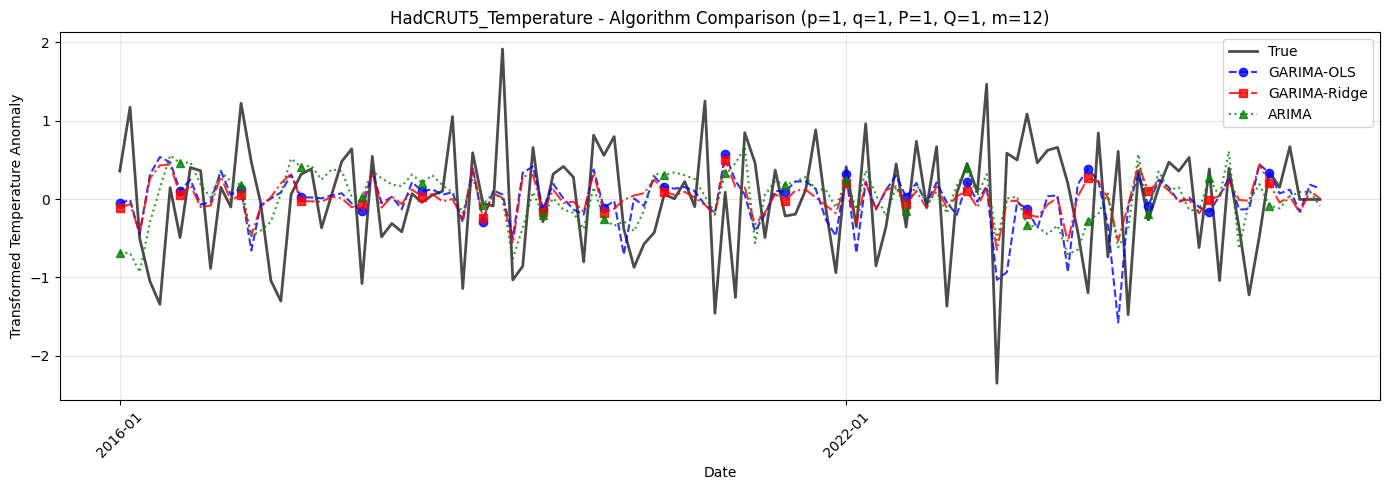


HadCRUT5_Temperature (p=1, q=1, P=1, Q=1):
  ARIMA           - MAE: 0.5693, RMSE: 0.7200, Time: 17.32s
  GARIMA-OLS      - MAE: 0.5669, RMSE: 0.7340, Time: 0.11s
  GARIMA-Ridge    - MAE: 0.5551, RMSE: 0.7110, Time: 0.12s



In [7]:
import os
import matplotlib.dates as mdates

# Create folder for plots if it doesn't exist
plot_dir = "HadCRUT5_comparison_plots"
os.makedirs(plot_dir, exist_ok=True)

# Plot comparison of all three algorithms
for name, series in datasets.items():
    n = len(series)
    # Rolling window: test on last horizon points
    test_start_idx = n - horizon
    test_end_idx = n
    
    # Get dates for the test period
    date_index = date_indices[name]
    test_dates = date_index[test_start_idx:test_end_idx]
    y_true = series[test_start_idx:test_end_idx]
    
    for p, q, P, Q in orders:
        plt.figure(figsize=(14, 5))
        plt.plot(test_dates, y_true, 'k-', linewidth=2, label='True', alpha=0.7)
        
        # Plot each algorithm if it ran successfully
        colors = {'GARIMA-OLS': 'blue', 'GARIMA-Ridge': 'red', 'ARIMA': 'green'}
        markers = {'GARIMA-OLS': 'o', 'GARIMA-Ridge': 's', 'ARIMA': '^'}
        linestyles = {'GARIMA-OLS': '--', 'GARIMA-Ridge': '-.', 'ARIMA': ':'}
        
        for alg_name in ['GARIMA-OLS', 'GARIMA-Ridge', 'ARIMA']:
            key = (name, p, q, P, Q, alg_name)
            if key in first_run_preds:
                preds = first_run_preds[key]
                plt.plot(test_dates, preds, 
                        color=colors[alg_name], 
                        linestyle=linestyles[alg_name],
                        marker=markers[alg_name],
                        markevery=max(1, horizon//20),  # Show markers at reasonable intervals
                        label=alg_name,
                        alpha=0.8)
        
        plt.title(f"{name} - Algorithm Comparison (p={p}, q={q}, P={P}, Q={Q}, m={m_seasonal})", fontsize=12)
        plt.xlabel("Date")
        plt.ylabel("Transformed Temperature Anomaly")
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        
        # Format x-axis dates
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        year_interval = max(1, horizon // 20)
        plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=year_interval))
        plt.xticks(rotation=45)
        plt.tight_layout()

        plot_filename = f"{plot_dir}/{name}_p{p}_q{q}_P{P}_Q{Q}_m{m_seasonal}.png"
        plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {plot_filename}")

        plt.show()
        
        # Print error metrics for this parameter combo
        print(f"\n{name} (p={p}, q={q}, P={P}, Q={Q}):")
        subset = agg[(agg['Dataset'] == name) & 
                     (agg['p'] == p) & 
                     (agg['q'] == q) & 
                     (agg['P'] == P) & 
                     (agg['Q'] == Q)]
        if not subset.empty:
            for _, row in subset.iterrows():
                print(f"  {row['Alg']:15s} - MAE: {row['MAE']:.4f}, RMSE: {row['RMSE']:.4f}, Time: {row['combo_sec']:.2f}s")
        print()


SUMMARY: Algorithm Comparison for HadCRUT5 Temperature Forecasting

Overall Performance (averaged across all datasets and parameter combinations):
         Alg      MAE     RMSE  combo_sec
GARIMA-Ridge 0.557456 0.713262   0.097077
       ARIMA 0.562752 0.718242   5.494574
  GARIMA-OLS 0.563496 0.726554   0.082696

Saved summary table to: HadCRUT5_results/summary_comparison.txt

Best Algorithm Per Dataset (by RMSE):

HadCRUT5_Temperature:
  Best algorithm: GARIMA-Ridge
  MAE: 0.5575, RMSE: 0.7133
  All algorithms (sorted by RMSE):
    GARIMA-Ridge   : MAE=0.5575, RMSE=0.7133 ✓ (Winner)
    ARIMA          : MAE=0.5628, RMSE=0.7182   (+0.7% worse)
    GARIMA-OLS     : MAE=0.5635, RMSE=0.7266   (+1.9% worse)

Saved comparison plot to: HadCRUT5_results/algorithm_comparison.png


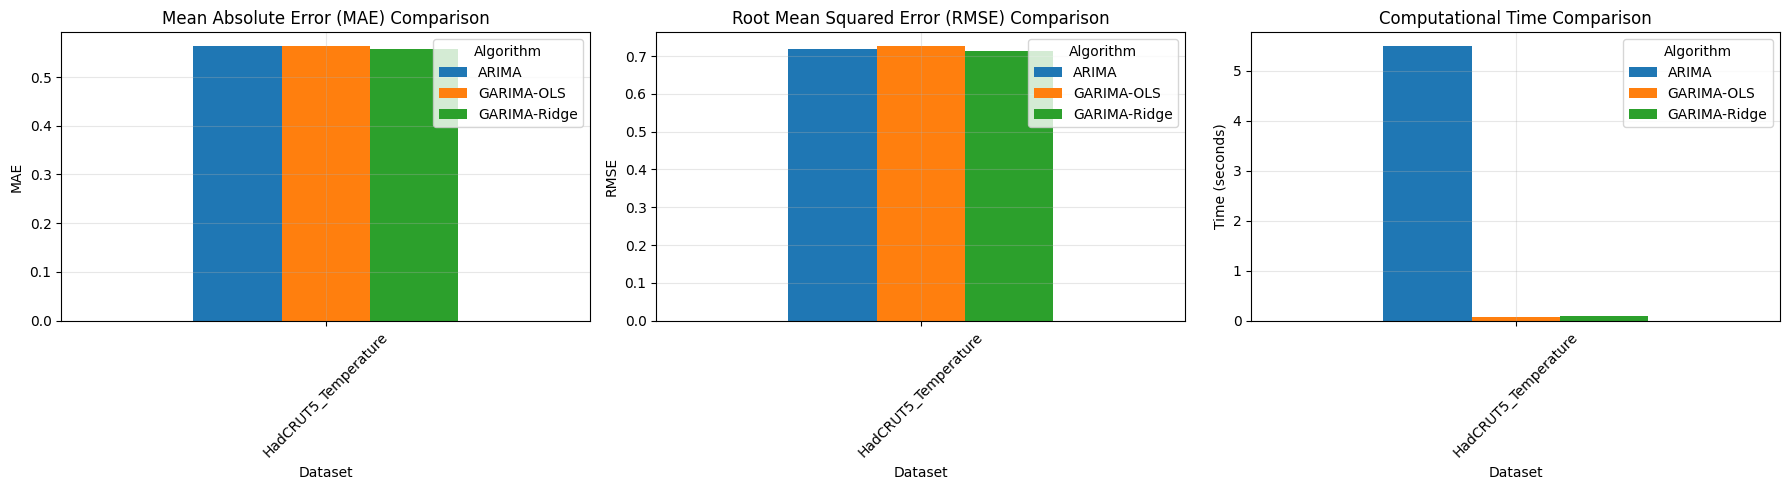


Computational Efficiency:
         Alg  mean_iter_ms  combo_sec  throughput_iters_per_sec
  GARIMA-OLS      0.688914   0.082696               1642.474026
GARIMA-Ridge      0.808748   0.097077               1380.629881
       ARIMA     45.787511   5.494574                 44.464128

Saved timing comparison to: HadCRUT5_results/timing_comparison.txt


In [8]:
import os

# Summary comparison across all algorithms
print("="*70)
print("SUMMARY: Algorithm Comparison for HadCRUT5 Temperature Forecasting")
print("="*70)

# Check if df exists (from Cell 4)
if 'df' not in locals() and 'df' not in globals():
    raise ValueError("Error: 'df' variable not found. Please run Cell 4 first to create the results DataFrame.")

# Overall average across all datasets
overall = df.groupby('Alg', as_index=False)[['MAE', 'RMSE', 'combo_sec']].mean()
overall = overall.sort_values('RMSE')

print("\nOverall Performance (averaged across all datasets and parameter combinations):")
print(overall.to_string(index=False))

# Save results to HadCRUT5-specific directory
results_dir = "HadCRUT5_results"
os.makedirs(results_dir, exist_ok=True)

with open(f"{results_dir}/summary_comparison.txt", 'w') as f:
    f.write("Overall Performance (averaged across all datasets and parameter combinations):\n")
    f.write("="*70 + "\n")
    f.write(overall.to_string(index=False))
print(f"\nSaved summary table to: {results_dir}/summary_comparison.txt")

# Best performer per dataset
print("\n" + "="*70)
print("Best Algorithm Per Dataset (by RMSE):")
print("="*70)

for dataset in df['Dataset'].unique():
    dataset_df = df[df['Dataset'] == dataset]
    best = dataset_df.groupby('Alg', as_index=False)[['MAE', 'RMSE']].mean()
    best = best.sort_values('RMSE')
    winner = best.iloc[0]
    
    print(f"\n{dataset}:")
    print(f"  Best algorithm: {winner['Alg']}")
    print(f"  MAE: {winner['MAE']:.4f}, RMSE: {winner['RMSE']:.4f}")
    print(f"  All algorithms (sorted by RMSE):")
    for _, row in best.iterrows():
        # Calculate percentage difference from winner
        if row['Alg'] == winner['Alg']:
            status = "✓ (Winner)"
        else:
            diff_pct = ((row['RMSE'] - winner['RMSE']) / winner['RMSE']) * 100
            status = f"  (+{diff_pct:.1f}% worse)"
        print(f"    {row['Alg']:15s}: MAE={row['MAE']:.4f}, RMSE={row['RMSE']:.4f} {status}")

# Create bar plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE comparison
mae_pivot = df.groupby(['Dataset', 'Alg'])['MAE'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='MAE'
)
mae_pivot.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Mean Absolute Error (MAE) Comparison')
axes[0].set_ylabel('MAE')
axes[0].legend(title='Algorithm', loc='best')
axes[0].grid(True, alpha=0.3)

# RMSE comparison
rmse_pivot = df.groupby(['Dataset', 'Alg'])['RMSE'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='RMSE'
)
rmse_pivot.plot(kind='bar', ax=axes[1], rot=45)
axes[1].set_title('Root Mean Squared Error (RMSE) Comparison')
axes[1].set_ylabel('RMSE')
axes[1].legend(title='Algorithm', loc='best')
axes[1].grid(True, alpha=0.3)

# Timing comparison (computational efficiency)
timing_pivot = df.groupby(['Dataset', 'Alg'])['combo_sec'].mean().reset_index().pivot(
    index='Dataset', columns='Alg', values='combo_sec'
)
timing_pivot.plot(kind='bar', ax=axes[2], rot=45)
axes[2].set_title('Computational Time Comparison')
axes[2].set_ylabel('Time (seconds)')
axes[2].legend(title='Algorithm', loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()

# Save the comparison plot
comparison_plot_path = f"{results_dir}/algorithm_comparison.png"
plt.savefig(comparison_plot_path, dpi=150, bbox_inches='tight')
print(f"\nSaved comparison plot to: {comparison_plot_path}")
plt.show()

# Timing comparison
print("\n" + "="*70)
print("Computational Efficiency:")
print("="*70)
timing = df.groupby('Alg', as_index=False)[['mean_iter_ms', 'combo_sec', 'throughput_iters_per_sec']].mean()
timing = timing.sort_values('combo_sec')
print(timing.to_string(index=False))

# Save timing comparison
with open(f"{results_dir}/timing_comparison.txt", 'w') as f:
    f.write("Computational Efficiency (averaged across all runs and parameter combinations):\n")
    f.write("="*70 + "\n")
    f.write(timing.to_string(index=False))
print(f"\nSaved timing comparison to: {results_dir}/timing_comparison.txt")
